In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [3]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [5]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

In [7]:
df['date'].dtype #verfied that the date column is now in datetime format
df['date'].isna().sum() #checked for any parsing errors in the date column, there are 0 which means all dates were parsed successfully

np.int64(0)

In [8]:
df['headline_length'] = df['headline'].astype(str).apply(len)

In [9]:
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

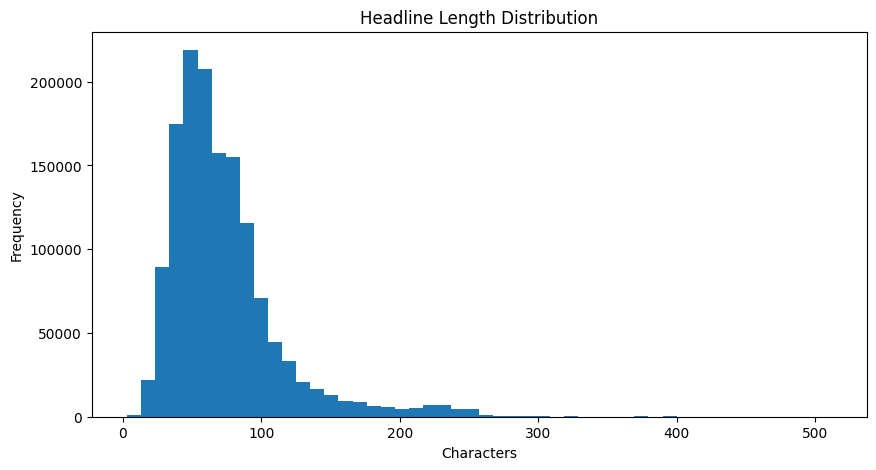

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df['headline_length'], bins=50)

plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

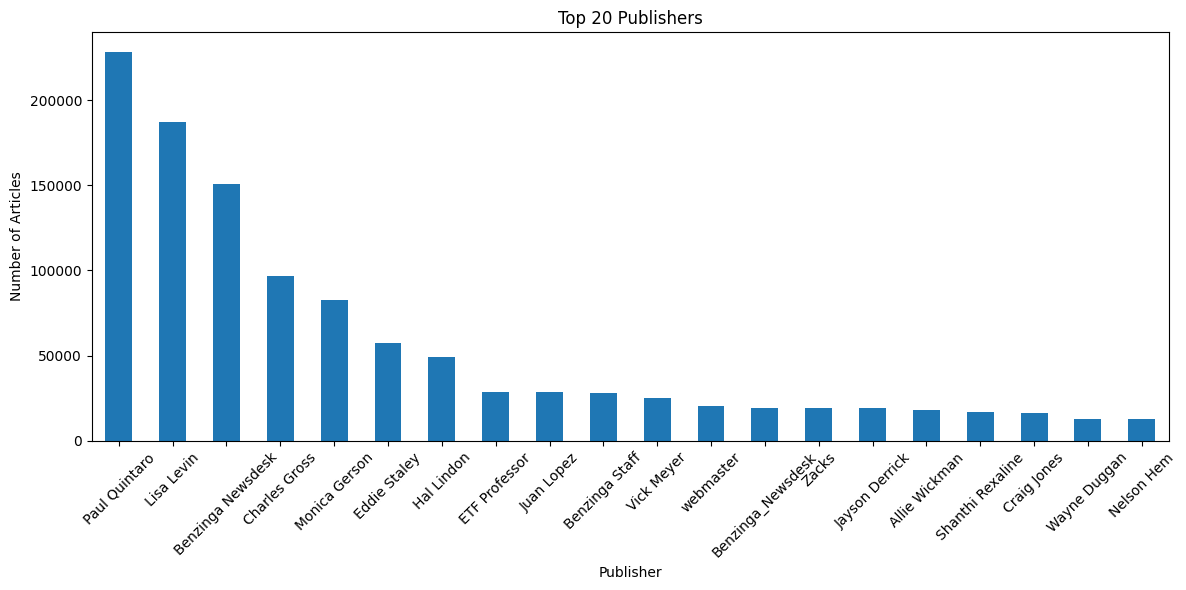

In [11]:
# Count top publishers
publisher_counts = df['publisher'].value_counts().head(20)

# Plot
plt.figure(figsize=(12,6))
publisher_counts.plot(kind='bar')

plt.title("Top 20 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
daily_counts = df.groupby(df['date'].dt.date).size()

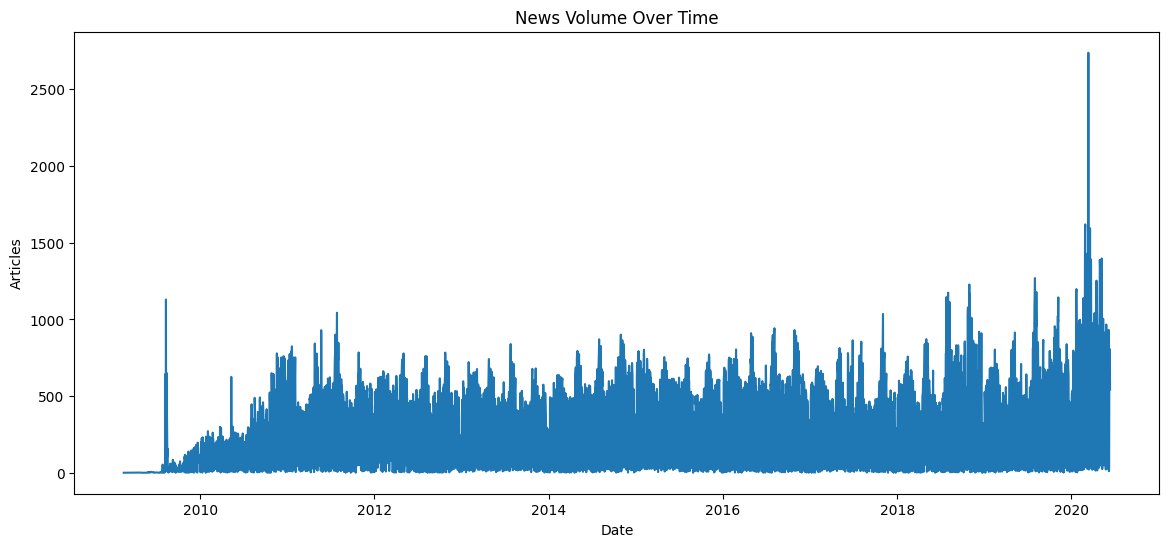

In [13]:
plt.figure(figsize=(14,6))

daily_counts.plot()

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Articles")

plt.show()

In [14]:
df['hour'] = df['date'].dt.hour

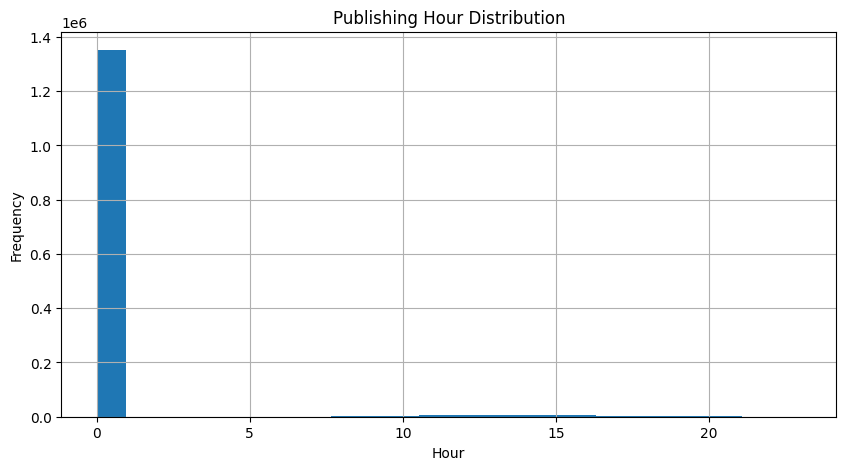

In [15]:
plt.figure(figsize=(10,5))

df['hour'].hist(bins=24)

plt.title("Publishing Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Frequency")

plt.show()

In [16]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['headline'].astype(str))

In [17]:
keywords = vectorizer.get_feature_names_out()

keywords

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports',
       'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week'],
      dtype=object)

In [18]:
keyword_scores = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    'keyword': keywords,
    'score': keyword_scores
})

keyword_df = keyword_df.sort_values(by='score', ascending=False)

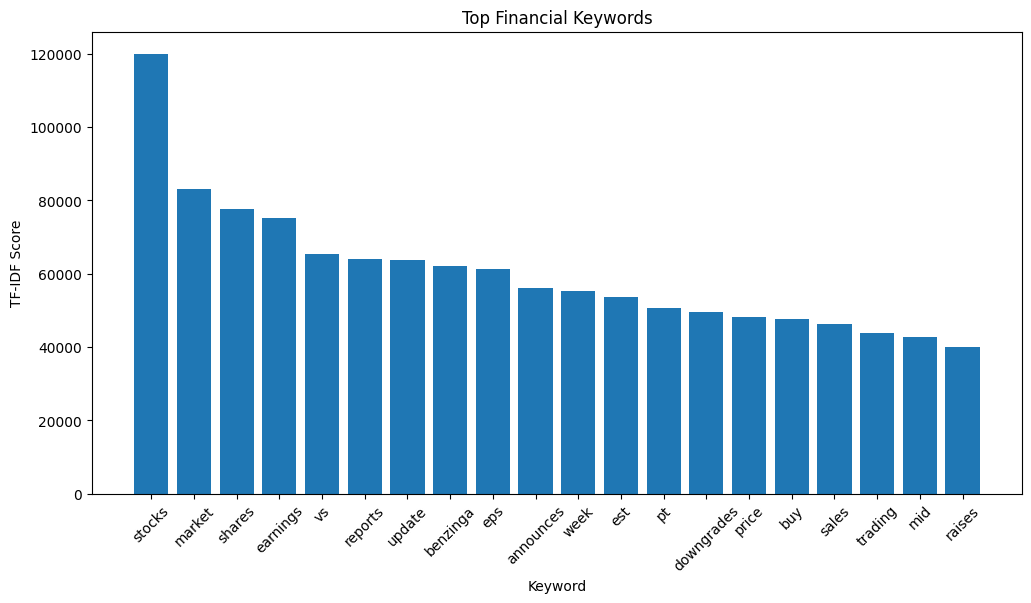

In [19]:
plt.figure(figsize=(12,6))

plt.bar(keyword_df['keyword'], keyword_df['score'])

plt.xticks(rotation=45)

plt.title("Top Financial Keywords")
plt.xlabel("Keyword")
plt.ylabel("TF-IDF Score")

plt.show()

In [20]:
df['domain'] = df['publisher'].astype(str).str.extract(r'@([\w\.-]+)')

In [21]:
domain_counts = df['domain'].value_counts().head(10)

domain_counts

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

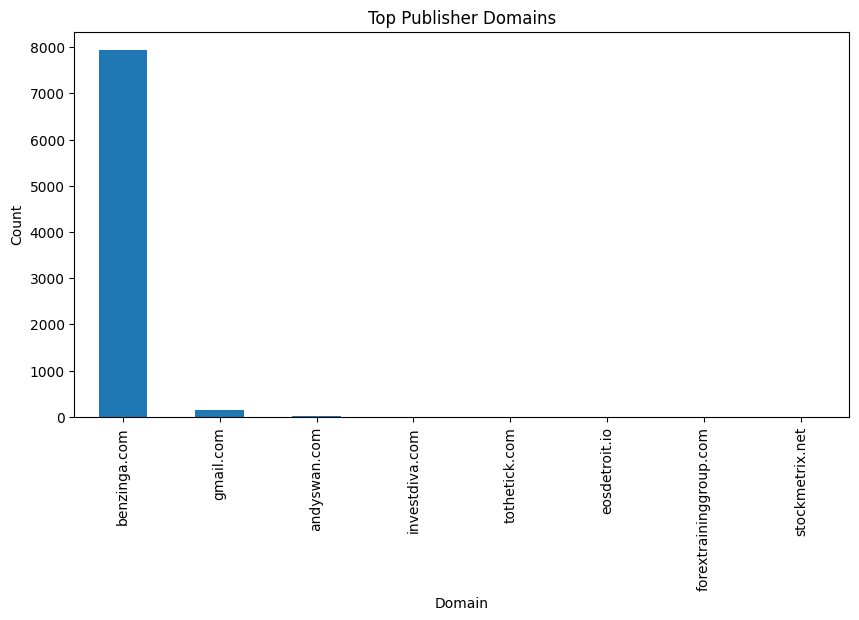

In [22]:
plt.figure(figsize=(10,5))

domain_counts.plot(kind='bar')

plt.title("Top Publisher Domains")
plt.xlabel("Domain")
plt.ylabel("Count")

plt.show()

In [23]:
stock_df.columns = stock_df.columns.str.strip().str.lower()
print(stock_df.columns)

NameError: name 'stock_df' is not defined

In [ ]:
print(stock_df.columns)
print(stock_df.head())


Index(['unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')
   unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10

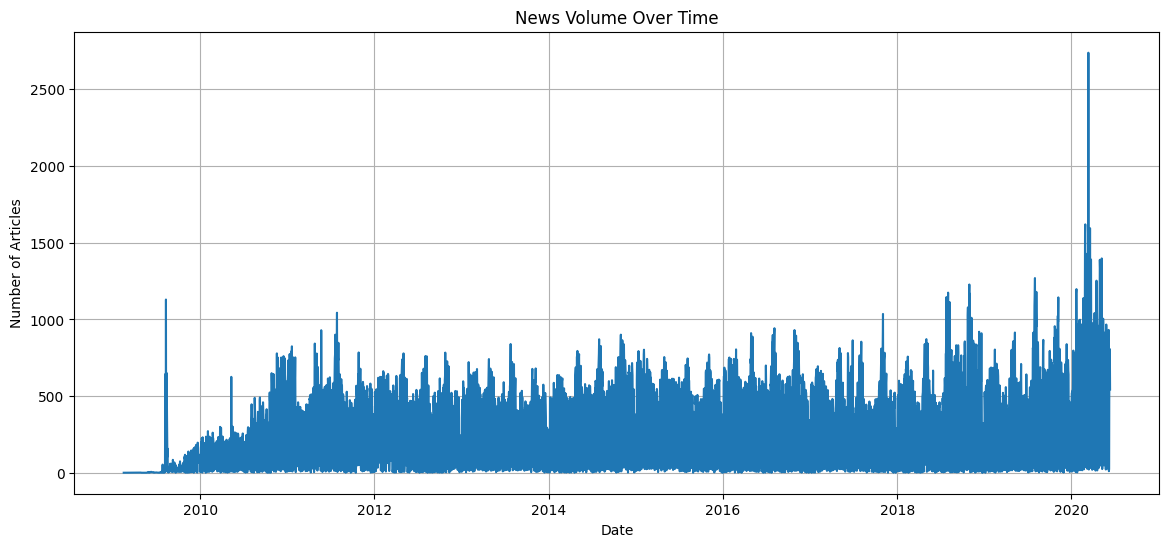

In [ ]:
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(14,6))
daily_counts.plot()

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid()
plt.show()

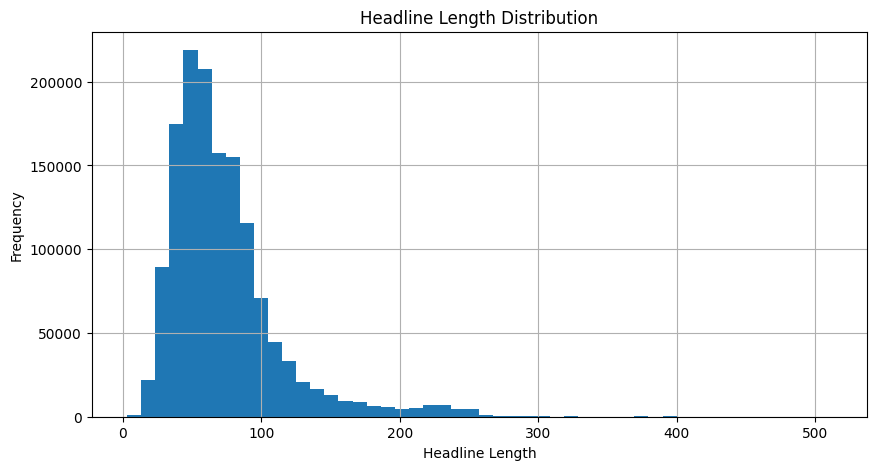

In [ ]:
df['headline_length'] = df['headline'].str.len()

plt.figure(figsize=(10,5))

plt.hist(df['headline_length'], bins=50)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [ ]:
print(stock_df.columns)

Index(['unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')
